**Superstore Sales Profitability Analysis**

**1. Data Exploration and Processing:**

● Importing necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

● Reading the dataset

In [ ]:
df = pd.read_csv('/content/Superstore Dataset.csv', encoding='latin1')

● Checking the shape of the dataset

In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (9994, 21)


● Data types of each column

In [ ]:
print("\nData Types:\n", df.dtypes)


Data Types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


● Detect missing values

In [ ]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


● Checking for duplicate values

In [ ]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


**2. Statistical Summary:**

● Provide an analysis of the statistical summary in a few lines for both categorical and numerical features.

In [ ]:
print("\nNumerical Summary:\n", df.describe())
print("\nCategorical Summary:\n", df.describe(include='object'))


Numerical Summary:
             Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656896  
std     234.260108  
min   -6599.978000  
25%       1.728750  
50%       8.666500  
75%      29.364000  
max    8399.976000  

Categorical Summary:
               Order ID Order Date   Ship Date       Ship Mode Customer ID  \
count

**3. Non-Graphical Analysis:**

Use value_counts() for all categorical features

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\nValue Counts for {col}:\n", df[col].value_counts())


Value Counts for Order ID:
 Order ID
CA-2017-100111    14
CA-2017-157987    12
CA-2016-165330    11
US-2016-108504    11
US-2015-126977    10
                  ..
CA-2014-110422     1
CA-2016-125794     1
CA-2017-163566     1
US-2015-151435     1
CA-2016-130225     1
Name: count, Length: 5009, dtype: int64

Value Counts for Order Date:
 Order Date
9/5/2016      38
9/2/2017      36
11/10/2016    35
12/1/2017     34
12/2/2017     34
              ..
1/28/2016      1
11/9/2016      1
6/3/2016       1
4/12/2015      1
1/21/2014      1
Name: count, Length: 1237, dtype: int64

Value Counts for Ship Date:
 Ship Date
12/16/2015    35
9/26/2017     34
11/21/2017    32
12/6/2017     32
9/6/2017      30
              ..
2/19/2016      1
2/1/2015       1
8/25/2016      1
1/27/2014      1
1/23/2014      1
Name: count, Length: 1334, dtype: int64

Value Counts for Ship Mode:
 Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int

Unique Attributes for all categorical features

In [ ]:
print(f"\nUnique Values for {col}: {df[col].nunique()}")


Unique Values for Product Name: 1850


**4. Graphical Analysis:**

**Univariate Analysis - Numerical Features:**

Distribution Plot

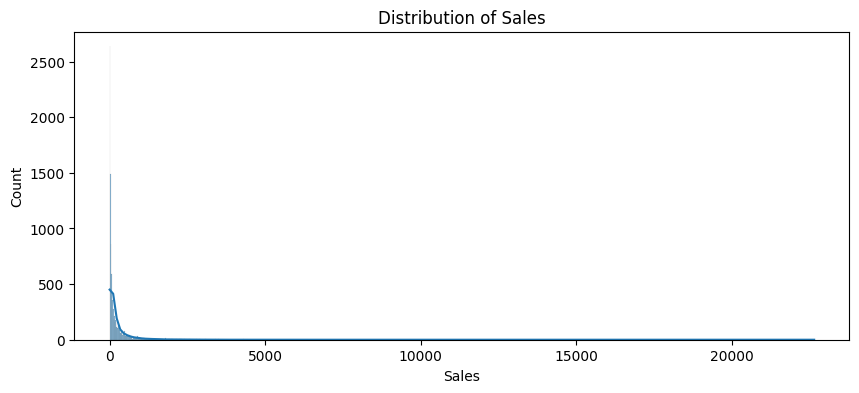

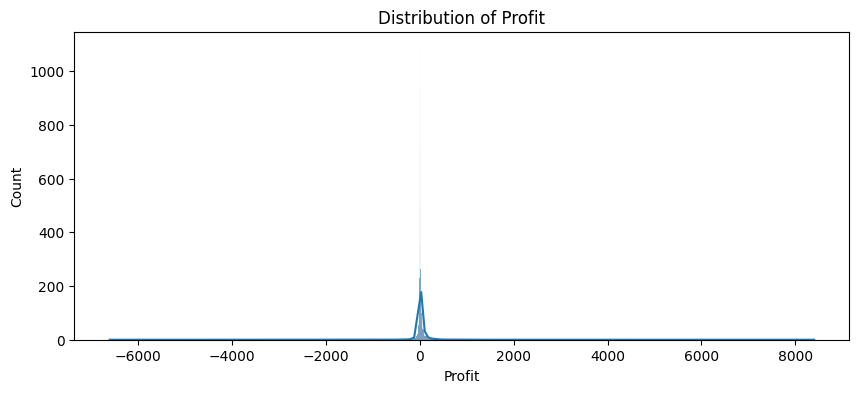

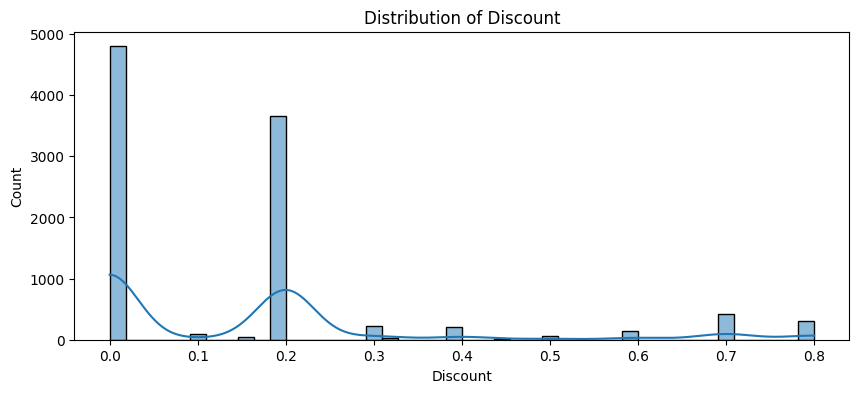

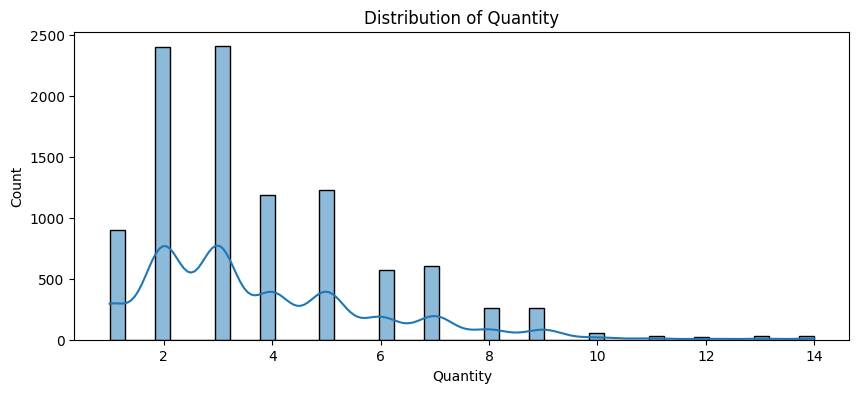

In [ ]:
for col in ['Sales', 'Profit', 'Discount', 'Quantity']:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

● Count Plot

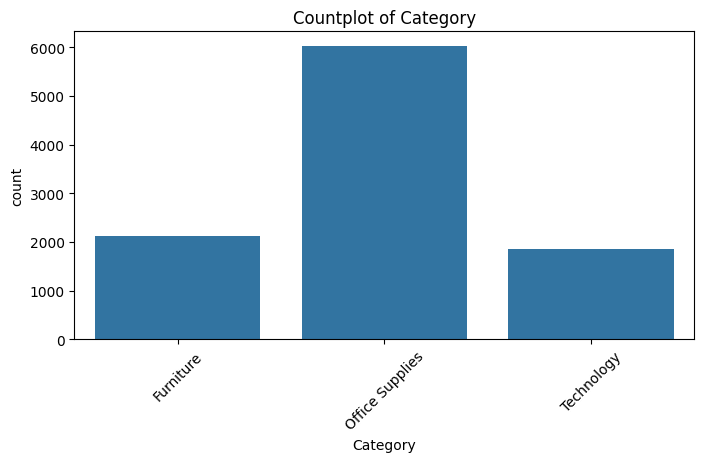

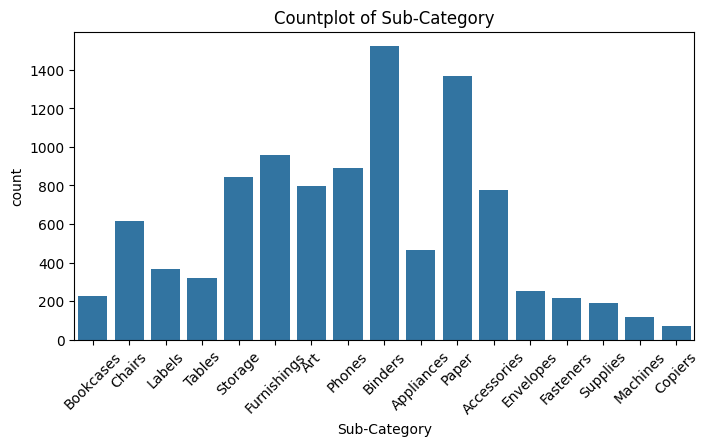

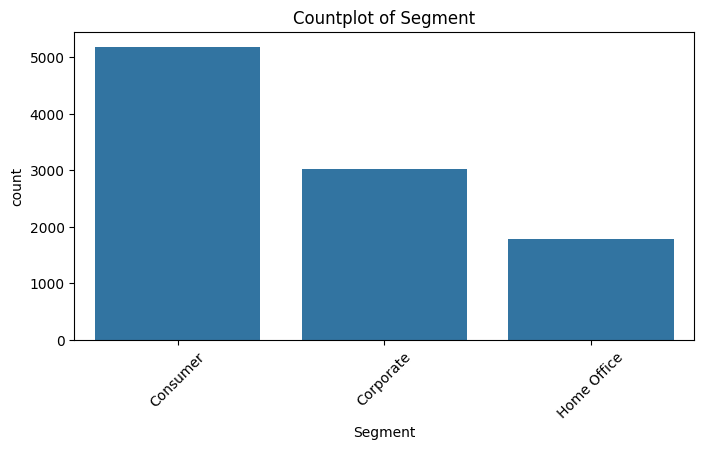

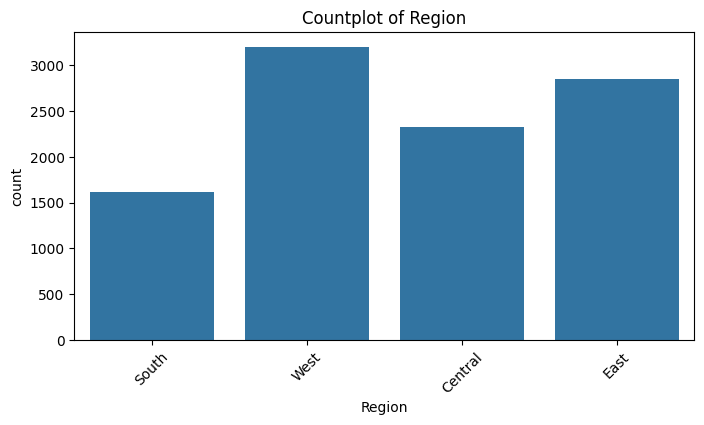

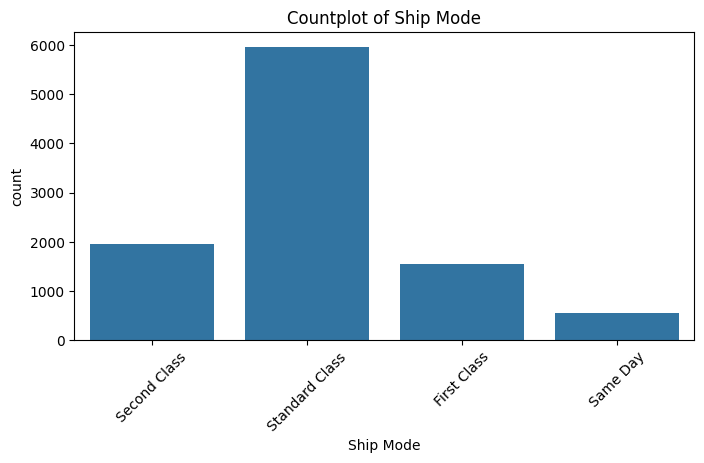

In [ ]:
for col in ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.show()

● Box Plot

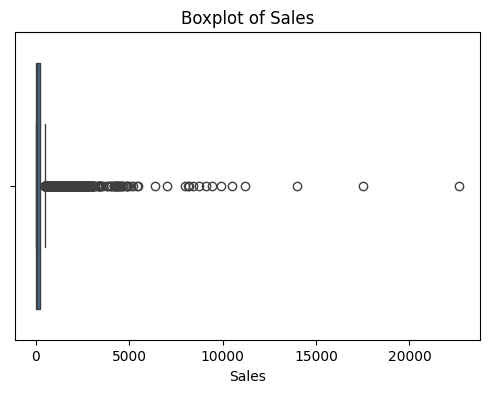

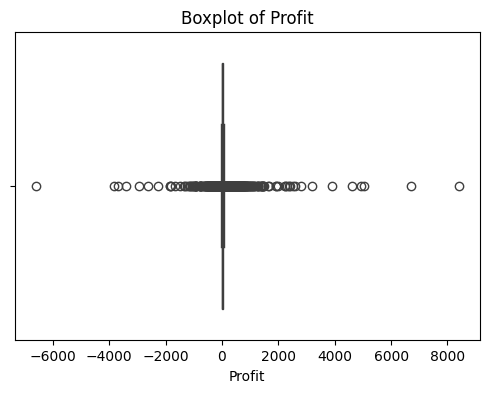

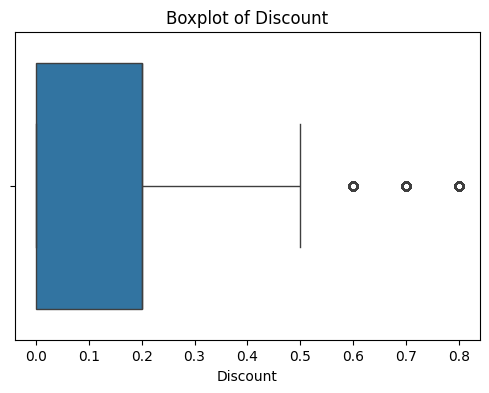

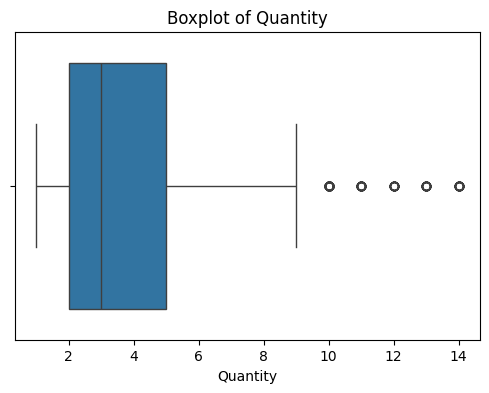

In [ ]:
for col in ['Sales', 'Profit', 'Discount', 'Quantity']:
    plt.figure(figsize=(6,4)) #Fixed: Indentation aligned with the for loop
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

**Univariate Analysis - Categorical Features:**

● Count Plot

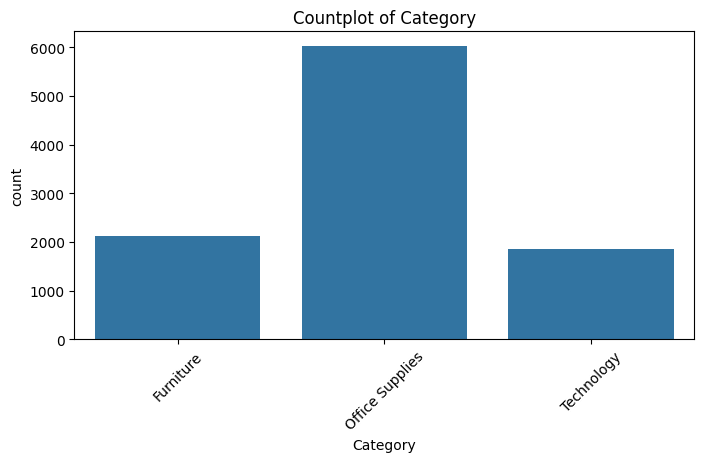

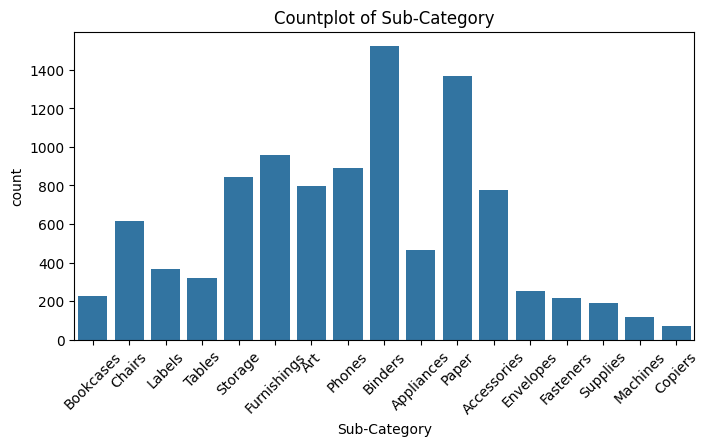

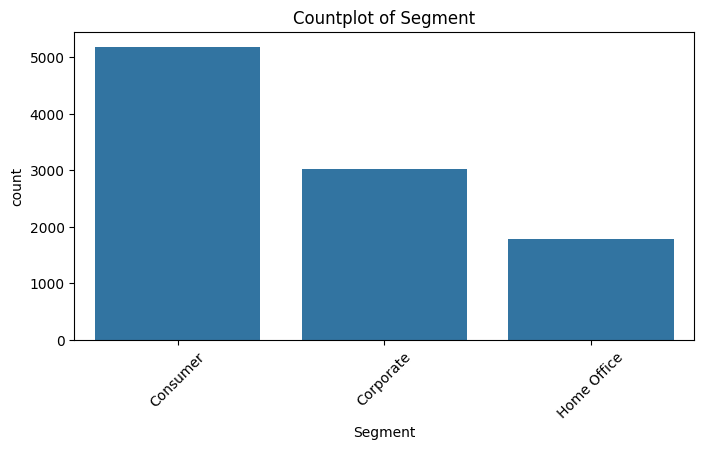

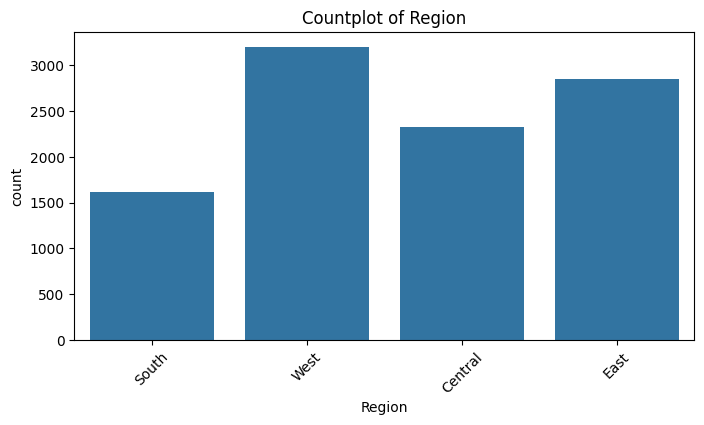

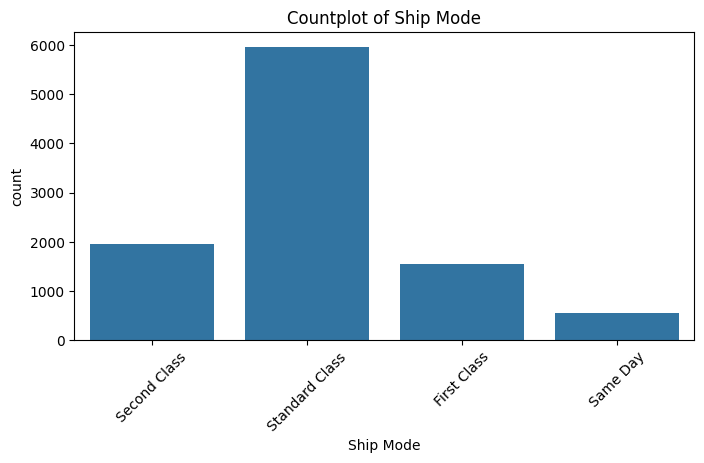

In [ ]:
for col in ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.show()

**Bivariate Analysis:**

● Explore how different features affect Sales/Profit, e.g.

● Sales vs Category / Sub-Category: Compare Sales across product categories and subcategories.

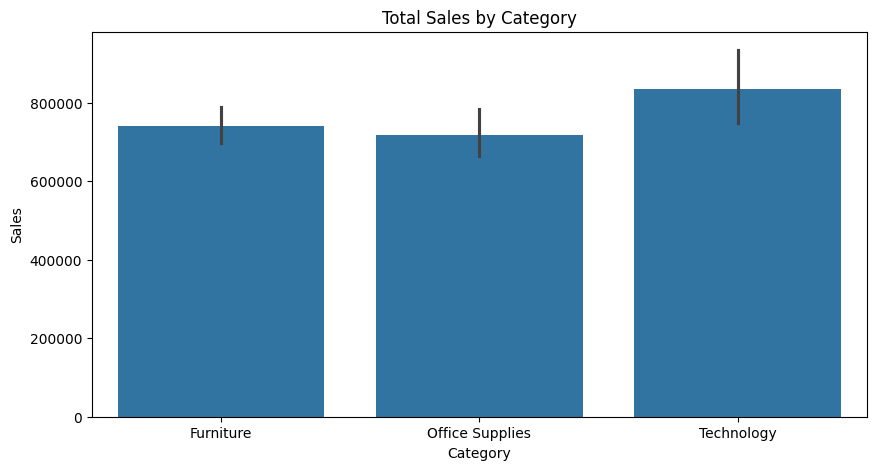

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum)
plt.title('Total Sales by Category')
plt.show()

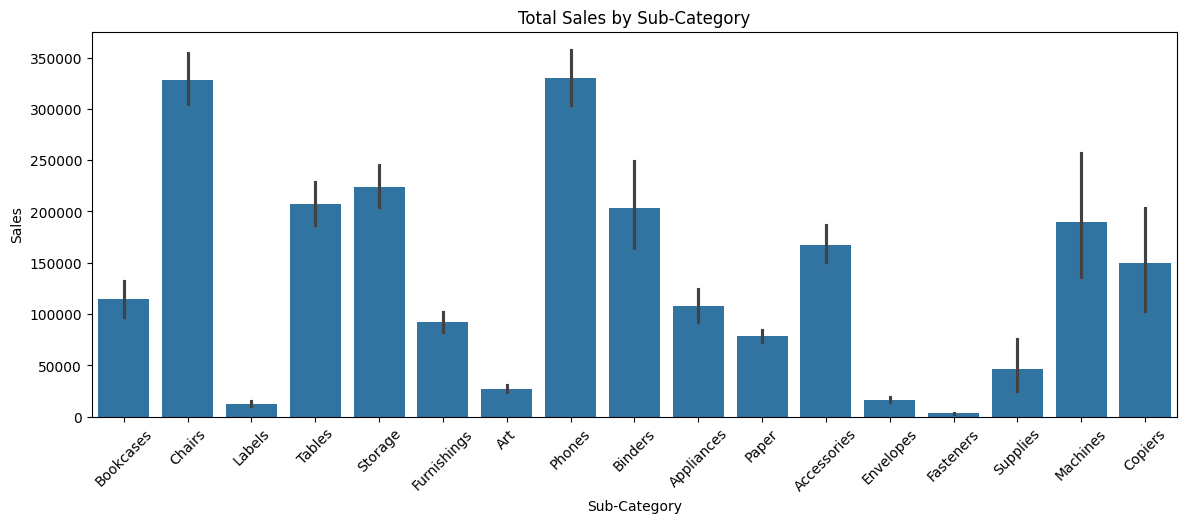

In [ ]:
plt.figure(figsize=(14,5))
sns.barplot(x='Sub-Category', y='Sales', data=df, estimator=sum)
plt.title('Total Sales by Sub-Category')
plt.xticks(rotation=45)
plt.show()

● Profit vs Discount: Understand how different discount levels impact profit. Look for threshold points where profit turns negative.

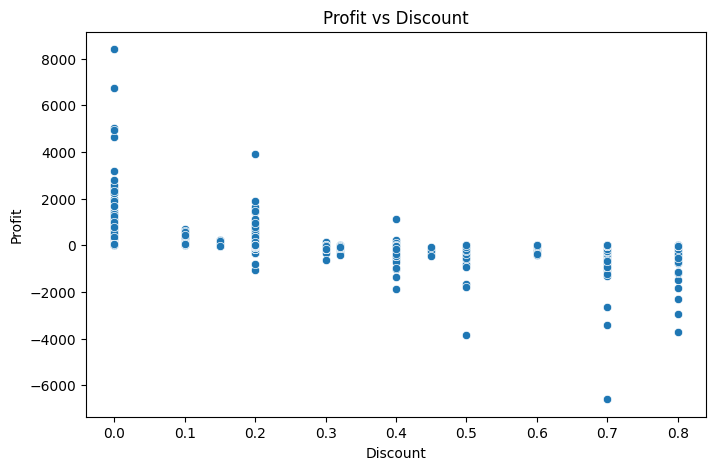

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title('Profit vs Discount')
plt.show()

**● Profit vs Sales:** Identify if higher sales always lead to higher profits or if losses exist in high sales.

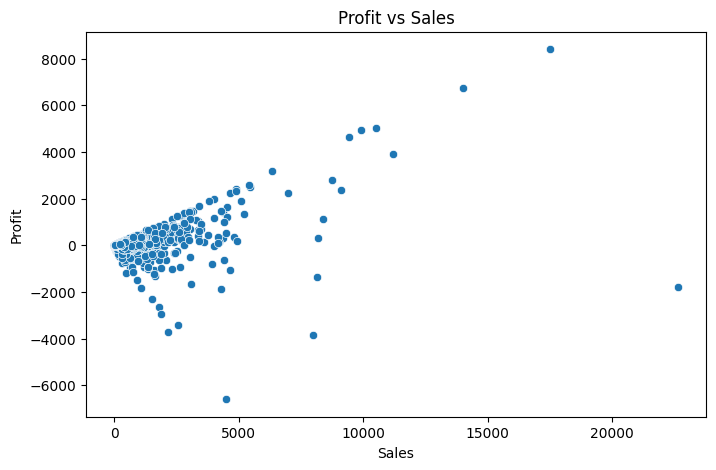

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Profit vs Sales')
plt.show()

**● Profit vs Category / Sub-Category:** Compare profitability across product categories and subcategories.

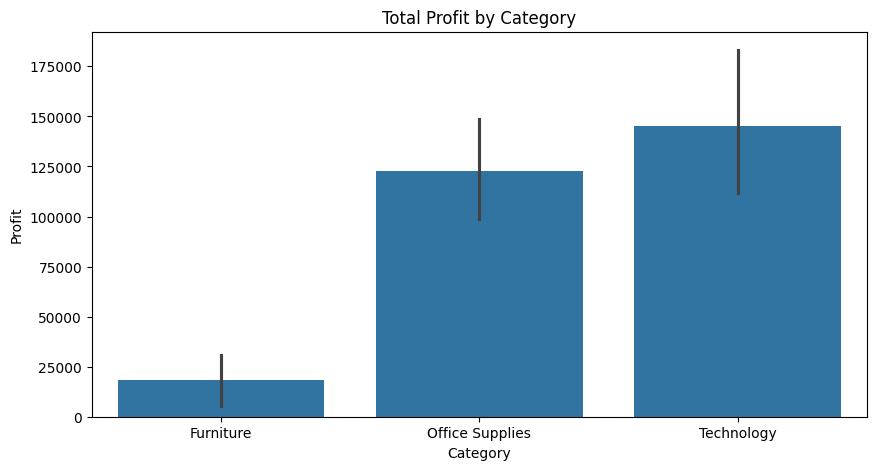

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Category', y='Profit', data=df, estimator=sum)
plt.title('Total Profit by Category')
plt.show()

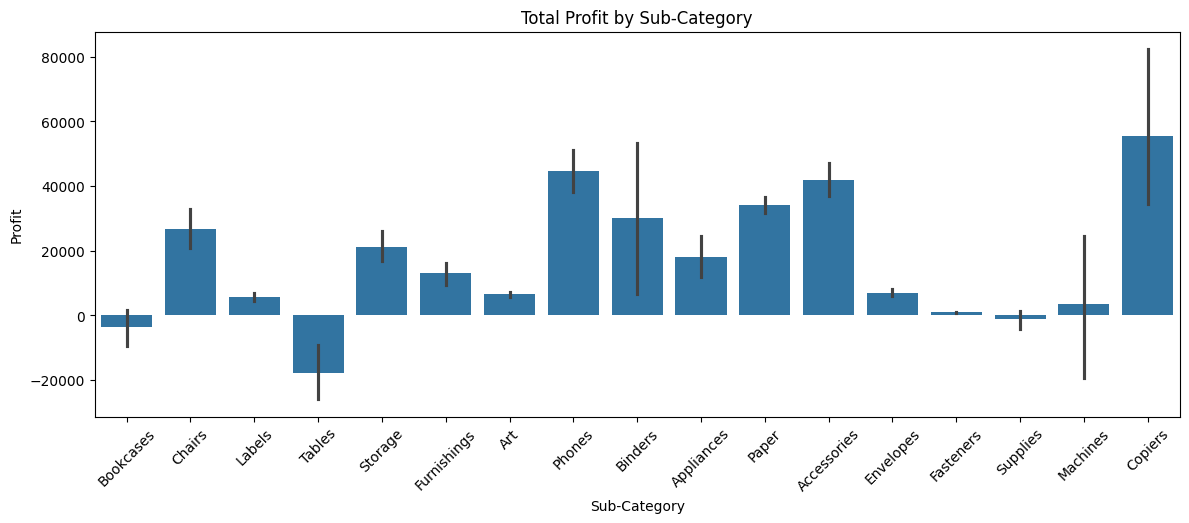

In [ ]:
plt.figure(figsize=(14,5))
sns.barplot(x='Sub-Category', y='Profit', data=df, estimator=sum)
plt.title('Total Profit by Sub-Category')
plt.xticks(rotation=45)
plt.show()

**Profit vs Segment:** Analyze which customer segments contribute the most to profit.

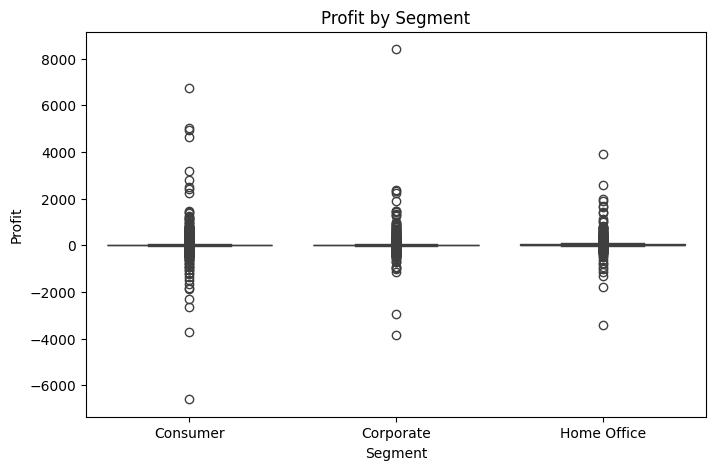

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Segment', y='Profit', data=df)
plt.title('Profit by Segment')
plt.show()

**● Profit vs Region / State:** Detect regional performance disparities and spot high/low-profit zones.

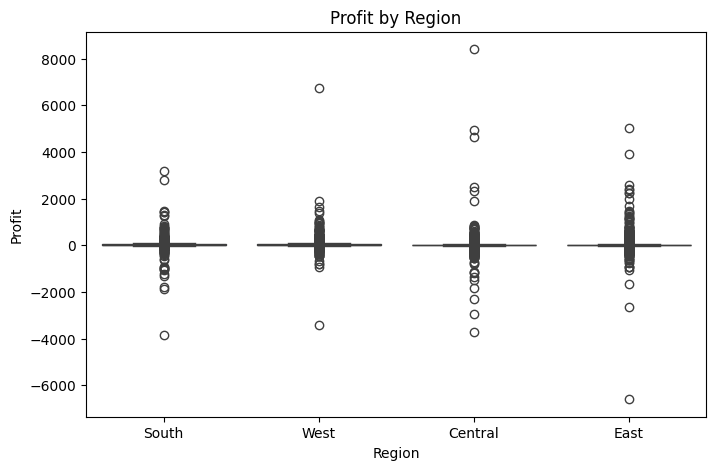

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Region', y='Profit', data=df)
plt.title('Profit by Region')
plt.show()

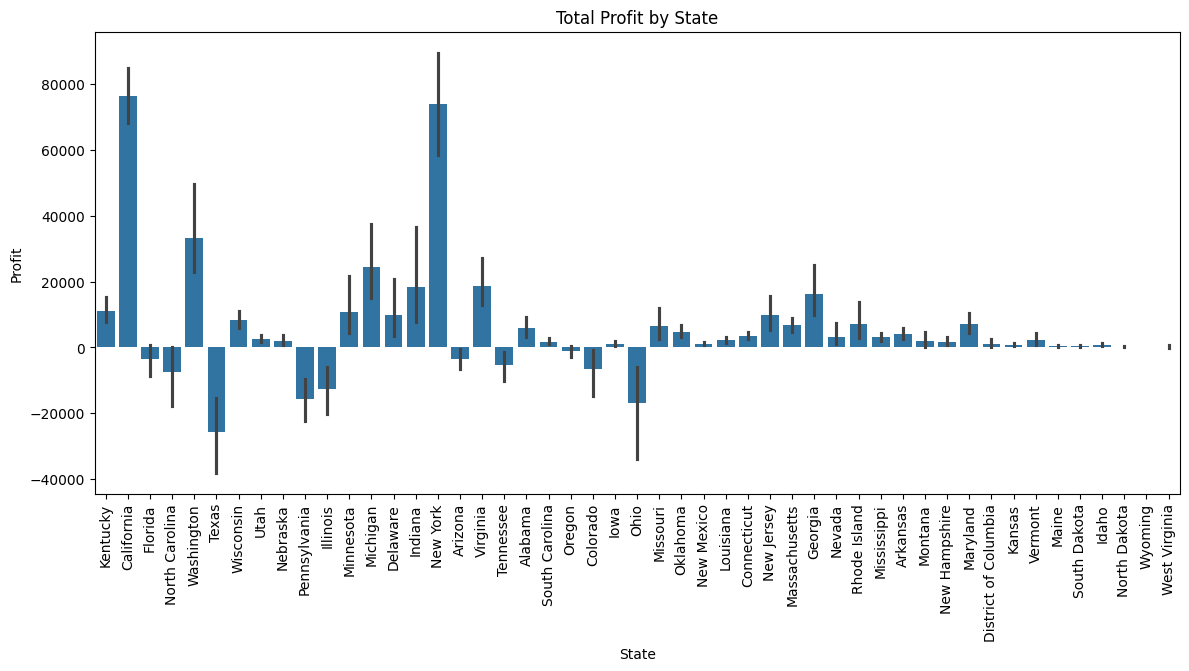

In [ ]:
plt.figure(figsize=(14,6))
sns.barplot(x='State', y='Profit', data=df, estimator=sum)
plt.title('Total Profit by State')
plt.xticks(rotation=90)
plt.show()

**● Profit vs Ship Mode:** Check if certain shipping methods are more profitable or cost-intensive.

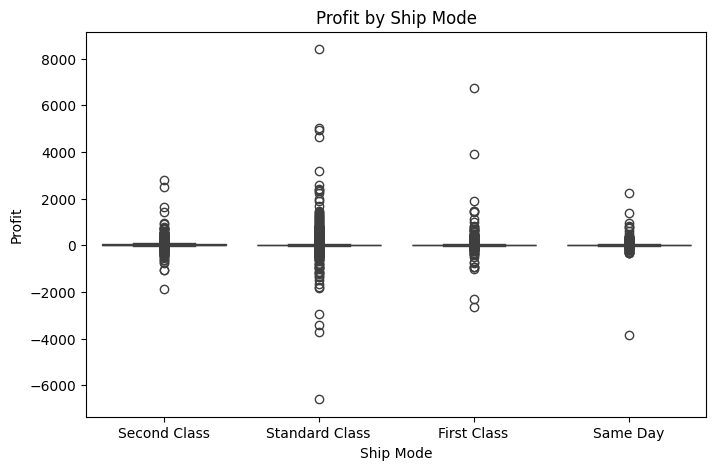

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Ship Mode', y='Profit', data=df)
plt.title('Profit by Ship Mode')
plt.show()

**● Profit vs Quantity:** See whether bulk orders are more profitable or result in losses due to discounts.

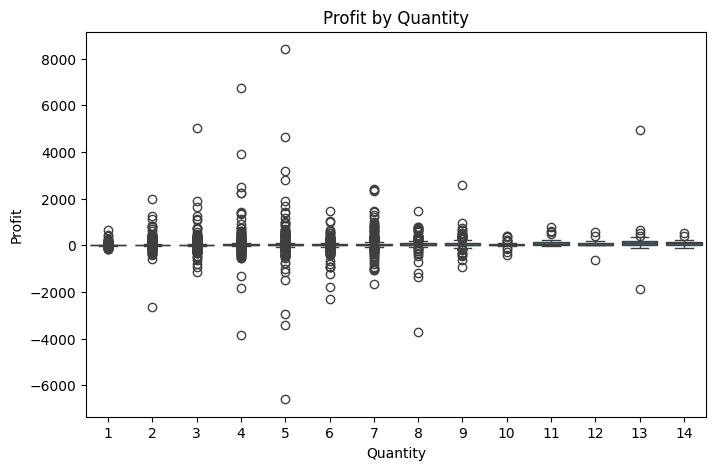

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Quantity', y='Profit', data=df)
plt.title('Profit by Quantity')
plt.show()

**● Profit vs Product Name:** Identify the 10 most and least profitable products.

In [ ]:
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values()
print("Top 10 Least Profitable Products:\n", product_profit.head(10))
print("Top 10 Most Profitable Products:\n", product_profit.tail(10))

Top 10 Least Profitable Products:
 Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64
Top 10 Most Profitable Products:
 Product Name
Zebra ZM400 Thermal Label Printer                                               3343.5

● **Profit vs Time (Month/Year):** Seasonal profitability trends, e.g., Q4 peak sales but lower margins.

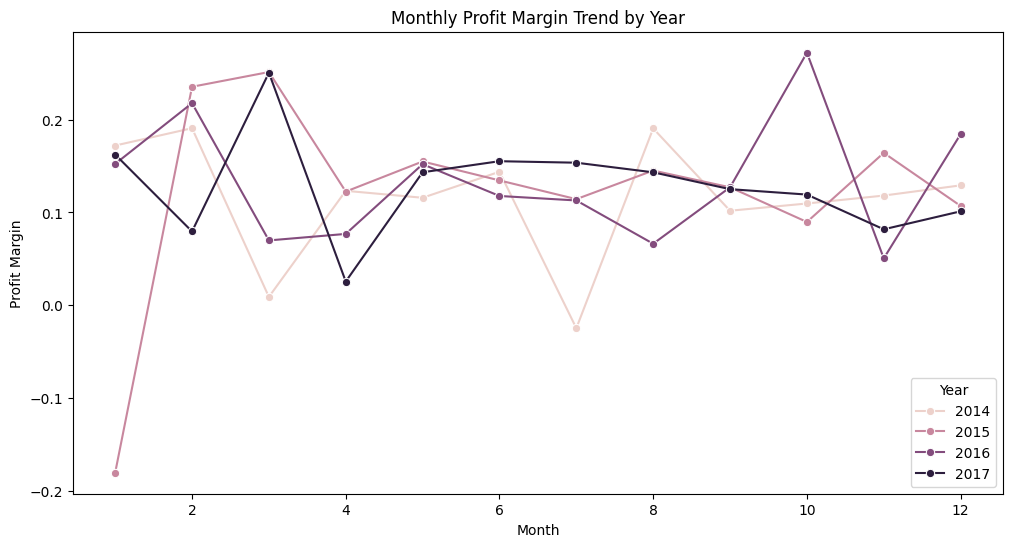

In [ ]:
# Extract Year and Month from 'Order Date' column
df['Order Date'] = pd.to_datetime(df['Order Date']) # Convert 'Order Date' to datetime
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Now you can group by 'Year' and 'Month'
monthly_data = df.groupby(['Year', 'Month']).agg({'Profit':'sum', 'Sales':'sum'}).reset_index()
monthly_data['Profit Margin'] = monthly_data['Profit'] / monthly_data['Sales']
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_data, x='Month', y='Profit Margin', hue='Year', marker='o')
plt.title('Monthly Profit Margin Trend by Year')
plt.show()

**Multivariate Analysis:**

● Create pairplots or grouped barplots to show relationships among multiple features. You can consider or take help from the given:

**● Segment + Region vs Profit:** Identify high-performing segments within each region.

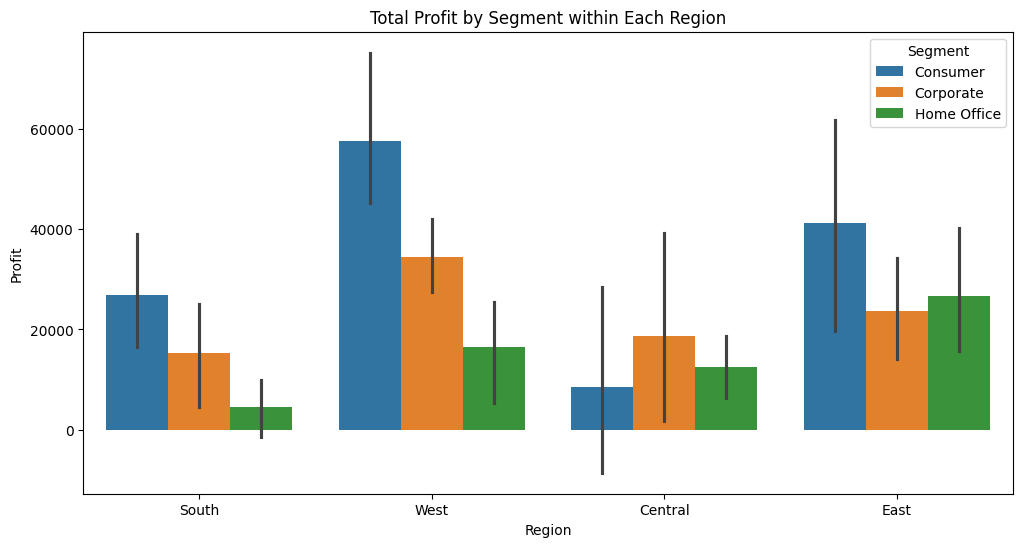

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='Region', y='Profit', hue='Segment', data=df, estimator=sum)
plt.title('Total Profit by Segment within Each Region')
plt.show()

**● Category + Discount vs Profit:** Analyze how discounts affect profitability across categories.

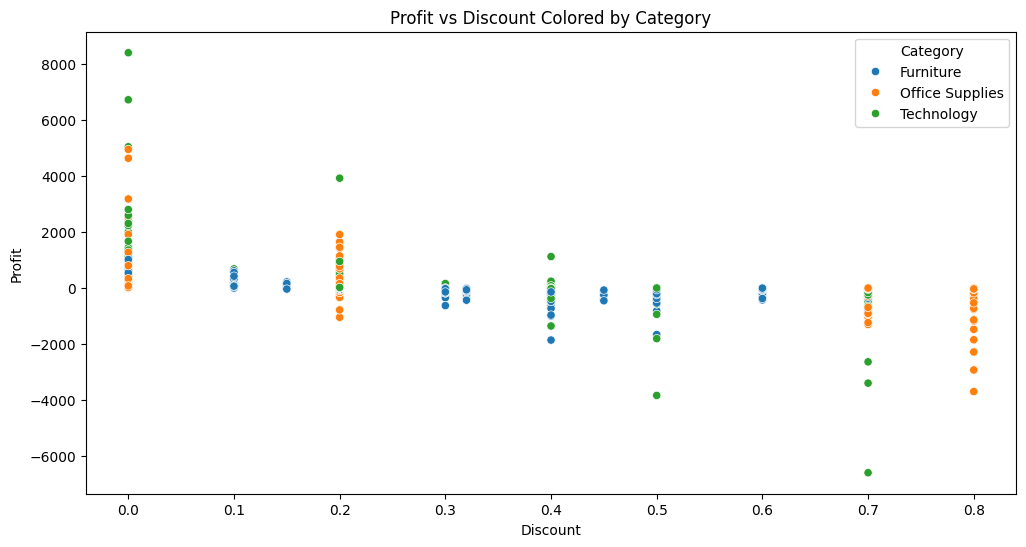

In [ ]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='Discount', y='Profit', hue='Category', data=df)
plt.title('Profit vs Discount Colored by Category')
plt.show()

**● Segment + Ship Mode vs Sales/Profit:** Understand how different segments use shipping methods and their associated performance.

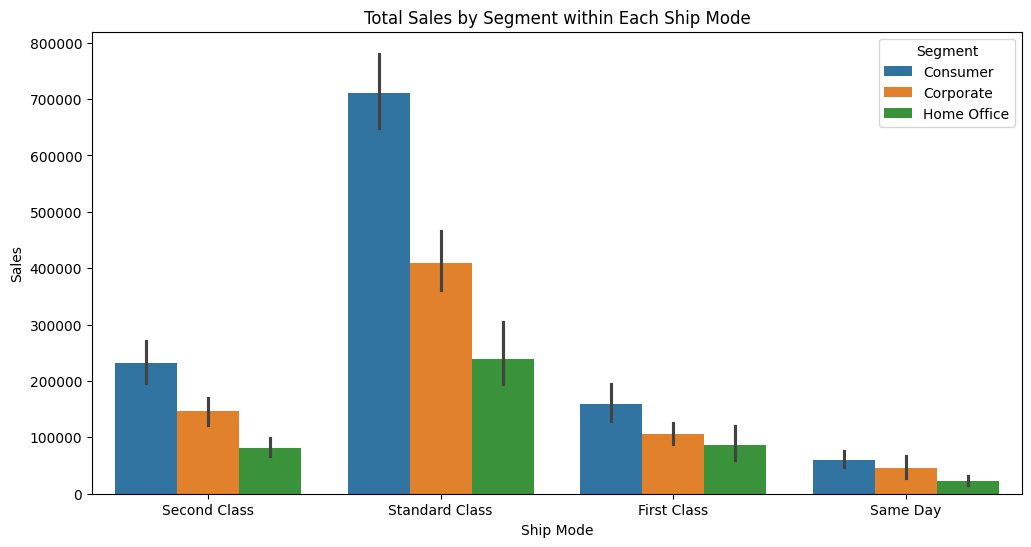

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='Ship Mode', y='Sales', hue='Segment', data=df, estimator=sum)
plt.title('Total Sales by Segment within Each Ship Mode')
plt.show()

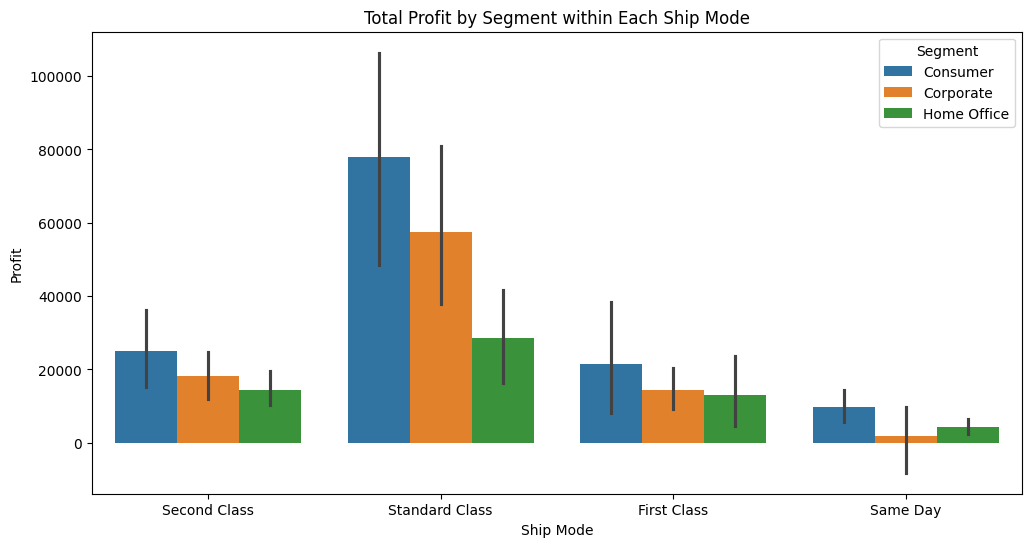

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='Ship Mode', y='Profit', hue='Segment', data=df, estimator=sum)
plt.title('Total Profit by Segment within Each Ship Mode')
plt.show()

**● Sub-Category + Region vs Profit (or Profit Margin) :** Find which sub-categories are strong in each region. (profit margin = Profit/Sales)

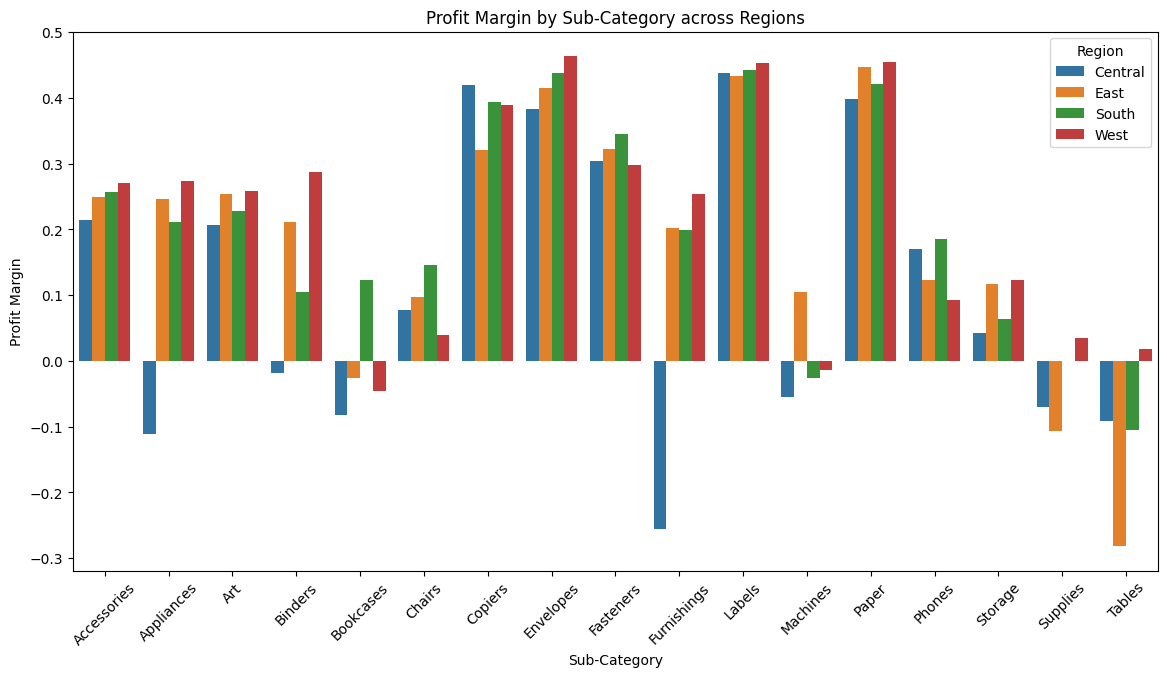

In [ ]:
subcat_region = df.groupby(['Sub-Category', 'Region']).agg({'Profit':'sum', 'Sales':'sum'}).reset_index()
subcat_region['Profit Margin'] = subcat_region['Profit'] / subcat_region['Sales']
plt.figure(figsize=(14,7))
sns.barplot(x='Sub-Category', y='Profit Margin', hue='Region', data=subcat_region)
plt.title('Profit Margin by Sub-Category across Regions')
plt.xticks(rotation=45)
plt.show()

**Time (Month/Year) + Category vs Profit:** Analyze seasonal or time-based trends in category-level performance.

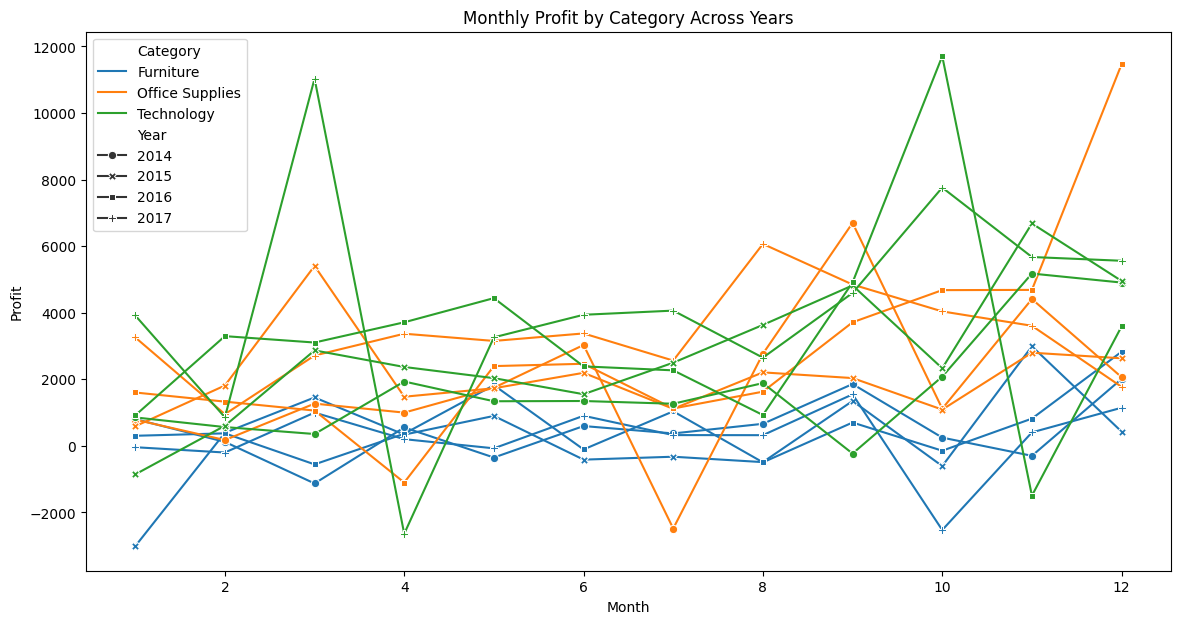

In [ ]:
time_category = df.groupby(['Year', 'Month', 'Category'])['Profit'].sum().reset_index()
plt.figure(figsize=(14,7))
sns.lineplot(data=time_category, x='Month', y='Profit', hue='Category', style='Year', markers=True, dashes=False)
plt.title('Monthly Profit by Category Across Years')
plt.show()

**● Region + Ship Mode + Profit:** Analyze if some shipping modes are more efficient/profitable in certain regions.

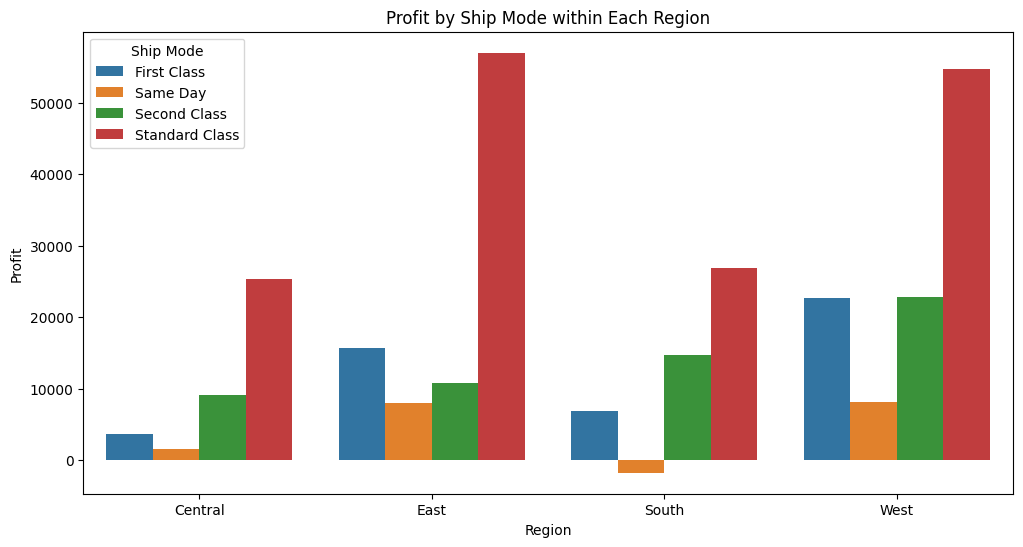

In [ ]:
region_ship = df.groupby(['Region', 'Ship Mode'])['Profit'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(x='Region', y='Profit', hue='Ship Mode', data=region_ship)
plt.title('Profit by Ship Mode within Each Region')
plt.show()

● Pairplot of Sales, Profit, Discount, and Quantity (Colored by Segment or Category)

Explore interactions and clusters across numerical features. Spot patterns, correlations, and outliers across different business segments or product categories.

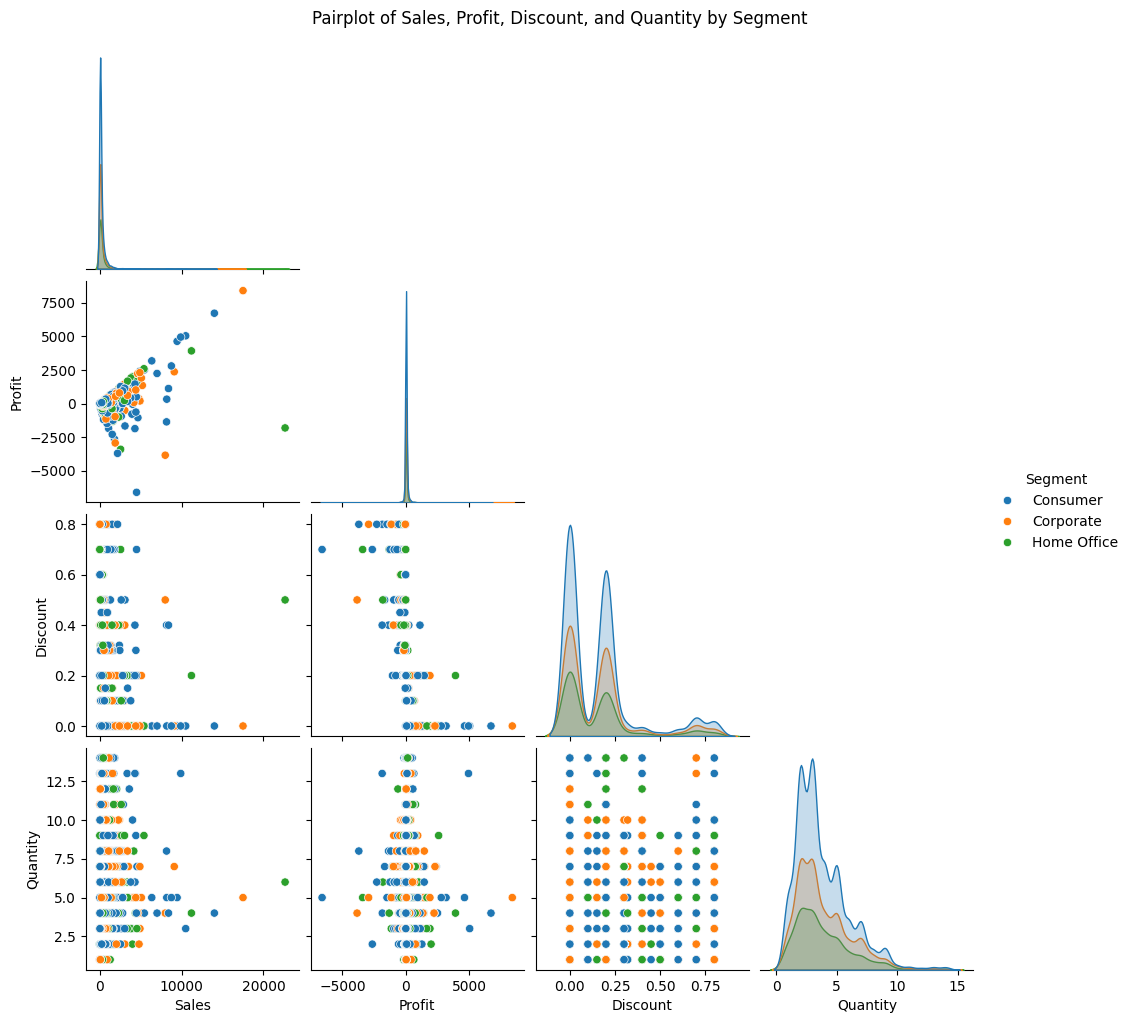

In [ ]:
sns.pairplot(df, vars=['Sales', 'Profit', 'Discount', 'Quantity'], hue='Segment', corner=True)
plt.suptitle('Pairplot of Sales, Profit, Discount, and Quantity by Segment', y=1.02)
plt.show()

**5. Correlation Analysis:**

● Display a correlation matrix using a heatmap

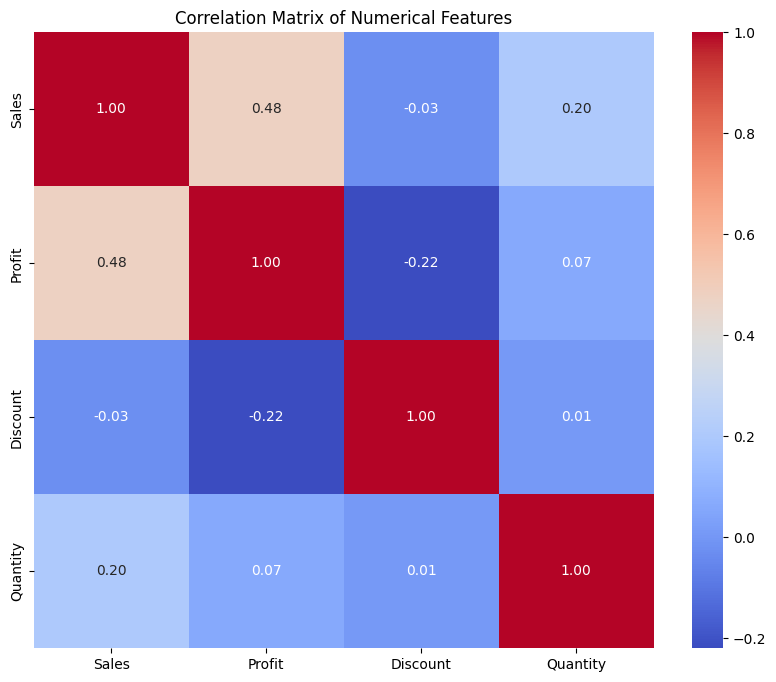

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df[['Sales', 'Profit', 'Discount', 'Quantity']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**6. Outlier Detection:**

● Use the IQR method or boxplots to detect outliers.

**1. Using the IQR Method for Outlier Detection**

In [ ]:
import pandas as pd

# Assuming your data is in the DataFrame 'df'
# Select only numerical features for outlier detection
numerical_df = df.select_dtypes(include=['number'])  # Select numerical columns only

# Calculate Q1 and Q3
Q1 = numerical_df.quantile(0.25)
Q3 = numerical_df.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define outliers for numerical features
outliers = ((numerical_df < (Q1 - 1.5 * IQR)) | (numerical_df > (Q3 + 1.5 * IQR)))

# Display rows with outliers in the original DataFrame (df)
outlier_data = df[outliers.any(axis=1)]  # Use original DataFrame for display
outlier_data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
10,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
11,12,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.4240,4,0.20,68.3568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9962,9963,CA-2015-168088,3/19/2015,3/22/2015,First Class,CM-12655,Corinna Mitchell,Home Office,United States,Houston,...,77041,Central,FUR-BO-10004218,Furniture,Bookcases,Bush Heritage Pine Collection 5-Shelf Bookcase...,383.4656,4,0.32,-67.6704
9968,9969,CA-2017-153871,12/11/2017,12/17/2017,Standard Class,RB-19435,Richard Bierner,Consumer,United States,Plainfield,...,7060,East,OFF-BI-10004600,Office Supplies,Binders,Ibico Ibimaster 300 Manual Binding System,735.9800,2,0.00,331.1910
9979,9980,US-2016-103674,12/6/2016,12/10/2016,Standard Class,AP-10720,Anne Pryor,Home Office,United States,Los Angeles,...,90032,West,OFF-BI-10002026,Office Supplies,Binders,Ibico Recycled Linen-Style Covers,437.4720,14,0.20,153.1152
9984,9985,CA-2015-100251,5/17/2015,5/23/2015,Standard Class,DV-13465,Dianna Vittorini,Consumer,United States,Long Beach,...,11561,East,OFF-LA-10003766,Office Supplies,Labels,Self-Adhesive Removable Labels,31.5000,10,0.00,15.1200


**2. Using Boxplots for Outlier Detection**

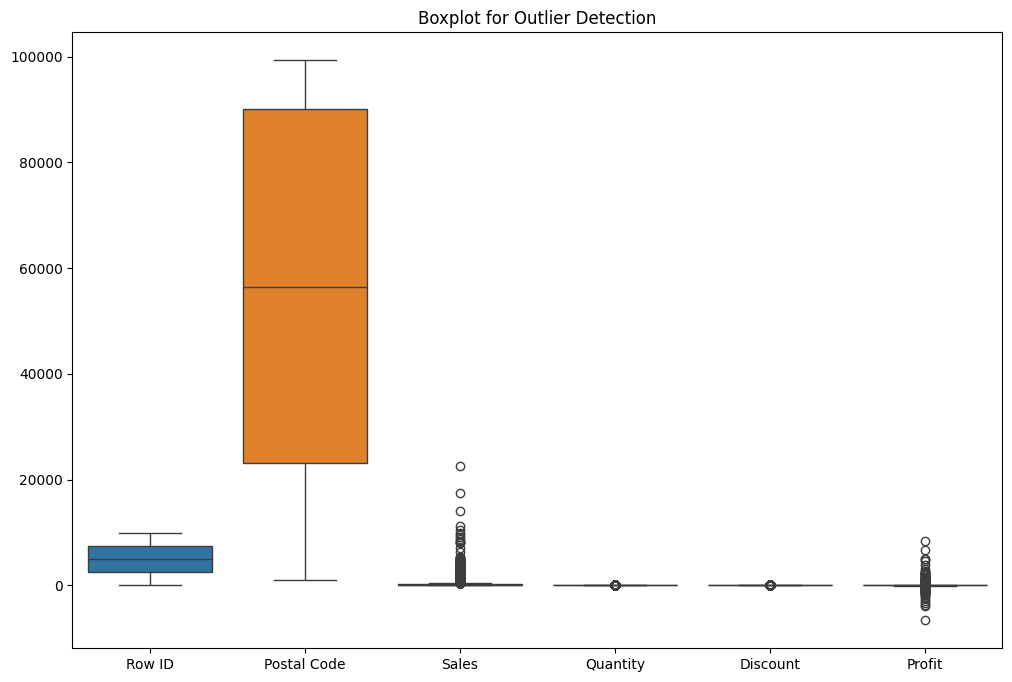

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a boxplot for each numerical column
plt.figure(figsize=(12, 8))
sns.boxplot(data=df)
plt.title('Boxplot for Outlier Detection')
plt.show()

**7. Conditional Analysis:**

● What percentage of orders come from each segment and region?

In [ ]:
import pandas as pd

# Assuming your dataset is loaded into 'df'
# Example column names: 'Segment', 'Region', and 'Order ID'  # Changed 'OrderID' to 'Order ID'

# Group by Segment and Region to count the number of orders in each group
order_counts = df.groupby(['Segment', 'Region']).size()

# Total number of orders
total_orders = df['Order ID'].nunique()  # Assuming 'Order ID' is unique for each order # Changed 'OrderID' to 'Order ID'

# Calculate the percentage of orders for each Segment and Region combination
order_percentages = (order_counts / total_orders) * 100

# Resetting index for easier readability
order_percentages = order_percentages.reset_index(name='Percentage')

# Display the result
order_percentages

,Segment,Region,Percentage
0,Consumer,Central,24.196446
1,Consumer,East,29.327211
2,Consumer,South,16.729886
3,Consumer,West,33.379916
4,Corporate,Central,13.435816
5,Corporate,East,17.508485
6,Corporate,South,10.181673
7,Corporate,West,19.165502
8,Home Office,Central,8.744260
9,Home Office,East,10.021960


● What are the average sales and profit per segment across different regions?

In [ ]:
import pandas as pd

# Assuming your dataset is loaded into 'df'
# Example columns: 'Segment', 'Region', 'Sales', 'Profit'

# Group by 'Segment' and 'Region' and calculate average sales and profit
avg_sales_profit = df.groupby(['Segment', 'Region'])[['Sales', 'Profit']].mean().reset_index()

# Display the result
avg_sales_profit


,Segment,Region,Sales,Profit
0,Consumer,Central,207.946728,7.066046
1,Consumer,East,238.875539,28.040153
2,Consumer,South,233.390180,32.116435
3,Consumer,West,217.033955,34.360409
4,Corporate,Central,234.763466,27.791831
5,Corporate,East,228.516929,26.935666
6,Corporate,South,238.992025,29.833771
7,Corporate,West,235.265911,35.872323
8,Home Office,Central,208.248046,28.398202
9,Home Office,East,253.911805,53.205611


How does discount level affect profitability across different categories?

In [ ]:
import pandas as pd

# Assuming your dataset is loaded into 'df'
# Example columns: 'Discount', 'Profit', 'Category'

# Group by Category and Discount level, then calculate average profit
avg_profit_discount = df.groupby(['Category', 'Discount'])['Profit'].mean().reset_index()

# Display the result
avg_profit_discount


,Category,Discount,Profit
0,Furniture,0.00,69.537173
1,Furniture,0.10,93.565946
2,Furniture,0.15,27.288298
3,Furniture,0.20,10.188535
4,Furniture,0.30,-48.177103
5,Furniture,0.32,-88.560656
6,Furniture,0.40,-215.831957
7,Furniture,0.45,-226.646464
8,Furniture,0.50,-238.355537
9,Furniture,0.60,-43.077212


● What percentage of high discount orders (>30%) result in negative profit?

In [ ]:
import pandas as pd

# Assuming your dataset is loaded into 'df'
# Example columns: 'Discount', 'Profit', 'OrderID'

# Step 1: Filter orders with discount > 30%
high_discount_orders = df[df['Discount'] > 0.3]  # Change to 0.3 for discount > 30%

# Step 2: Count how many of these high discount orders have negative profit
negative_profit_orders = high_discount_orders[high_discount_orders['Profit'] < 0]

# Step 3: Calculate the percentage of negative profit orders
if len(high_discount_orders) > 0:  # Check if there are high discount orders to avoid ZeroDivisionError
    percentage_negative_profit = (len(negative_profit_orders) / len(high_discount_orders)) * 100
else:
    percentage_negative_profit = 0  # Set percentage to 0 if no high discount orders

# Display the result
print(f"Percentage of high discount orders (>30%) with negative profit: {percentage_negative_profit:.2f}%")

Percentage of high discount orders (>30%) with negative profit: 97.77%


What percentage of customers are repeat buyers, and how do they differ in spending patterns?

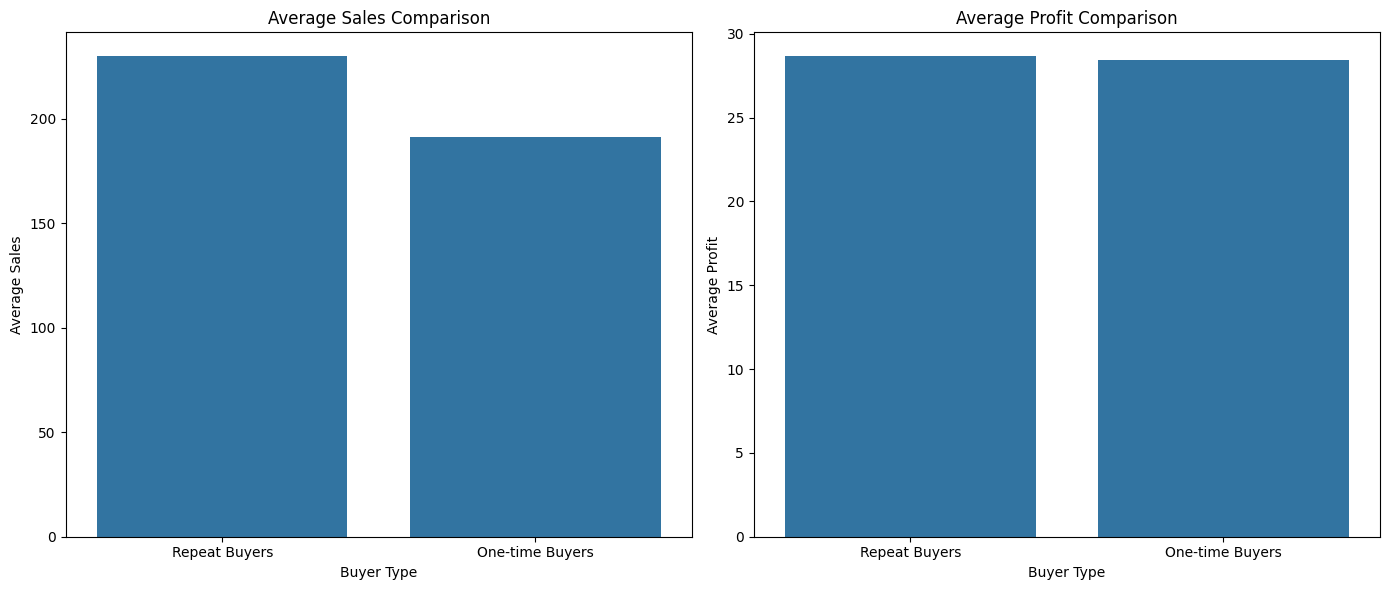

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataset is loaded into 'df' and has a 'Customer ID' column

# Calculate repeat buyers (customers with more than one order)
repeat_buyers = df.groupby('Customer ID')['Order ID'].nunique()  # Assuming 'Order ID' is unique for each order
repeat_buyers = repeat_buyers[repeat_buyers > 1].index.tolist()

# Calculate average sales and profit for repeat buyers
avg_sales_repeat = df[df['Customer ID'].isin(repeat_buyers)]['Sales'].mean()
avg_profit_repeat = df[df['Customer ID'].isin(repeat_buyers)]['Profit'].mean()

# Calculate average sales and profit for one-time buyers
one_time_buyers = df[~df['Customer ID'].isin(repeat_buyers)]['Customer ID'].unique()  # Get unique one-time buyers
avg_sales_one_time = df[df['Customer ID'].isin(one_time_buyers)]['Sales'].mean()
avg_profit_one_time = df[df['Customer ID'].isin(one_time_buyers)]['Profit'].mean()

# Create a dataframe for easy plotting
comparison_data = pd.DataFrame({
    'Buyer Type': ['Repeat Buyers', 'One-time Buyers'],
    'Average Sales': [avg_sales_repeat, avg_sales_one_time],
    'Average Profit': [avg_profit_repeat, avg_profit_one_time]
})

# Plot the comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot average sales
sns.barplot(x='Buyer Type', y='Average Sales', data=comparison_data, ax=ax[0])
ax[0].set_title('Average Sales Comparison')

# Plot average profit
sns.barplot(x='Buyer Type', y='Average Profit', data=comparison_data, ax=ax[1])
ax[1].set_title('Average Profit Comparison')

plt.tight_layout()
plt.show()